### 🤖 LLM and AI Agent Development Courses  
**✨ All courses available for just ₹399 INR / $9.99 USD ✨**

| Course | Description | Enroll |
|--------|-------------|---------|
| **🎯 Master OpenAI Agent Builder** | Build and deploy AI agents visually using OpenAI Agent Builder, ChatKit, RAG, Chatbot, AI Assistant with MCP, AWS, RDS MySQL | [Enroll Now](https://kgptalkie.com/agent-builder) |
| **🔥 MCP Mastery** | Build MCP servers & clients with Python, Streamlit, ChromaDB, LangChain, LangGraph agents, and Ollama integrations | [Enroll Now](https://kgptalkie.com/mcp) |
| **📊 Private Agentic RAG with LangChain** | Step-by-Step Guide to RAG with LangChain v1, LangGraph, and Ollama (Qwen3, Gemma3, DeepSeek-R1, LLAMA, FAISS) | [Enroll Now](https://kgptalkie.com/agentic-rag) |
| **🔧 Master LangGraph and LangChain** | Agentic RAG and Chatbot, AI Agent with LangChain v1, Qwen3, Gemma3, DeepSeek-R1, LLAMA 3.2, FAISS Vector Database | [Enroll Now](https://kgptalkie.com/langgraph) |
| **⚡ Master Langchain and Ollama** | Master Langchain v1, Local LLM Projects with Ollama, Qwen3, Gemma3, DeepSeek-R1, LLAMA 3.2, Complete Integration Guide | [Enroll Now](https://kgptalkie.com/langchain) |
| **🔬 Fine Tuning LLM** | Learn transformer architecture fundamentals and fine-tune LLMs with custom datasets | [Enroll Now](https://kgptalkie.com/fine-tuning-llm) |

---

### 🌐 Join the Community & Stay Connected

- 🔗 **Join the Discord Community:** https://discord.gg/RFjwbkNa  
- 📺 **Subscribe on YouTube (63K+ learners):** http://www.youtube.com/@KGPTalkie

---


## LangGraph ReAct Agent with Tools
Learning Objectives:
- Create tools (functions) that LLMs can call
- Implement the ReAct pattern (Reasoning + Acting)
- Build an agent that decides when to use tools

#### 
Real-World Tools:
-----------------
- Database queries
- API calls (weather, stock prices, etc.)
- File operations
- Web searches
- Send emails/notifications
- Execute code
- Image generation
- Data analysis

### Agent Patterns
- Chain of Thoughts (CoT)
- Tree of Thoughts (ToT)
- ReAct

In [1]:
import logging
from dotenv import load_dotenv
from langfuse.langchain import CallbackHandler

logging.getLogger("langfuse").setLevel(logging.ERROR)

load_dotenv()
langfuce_trace = CallbackHandler()

In [7]:
from typing_extensions import TypedDict, Annotated
import operator
import logging
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.prebuilt import ToolNode

# Configuration
BASE_URL = "http://localhost:11434"
MODEL_NAME = "qwen3" # llama 3.2
# MODEL_NAME = "llama3.2" # llama 3.2
# gemma3, deepseek-r1 -< they don't have tools support yet

llm = ChatOllama(model=MODEL_NAME, base_url=BASE_URL)

In [8]:
class AgentState(TypedDict):
    messages: Annotated[list, operator.add]

#### Agent Node

In [9]:
## Tool usage
import my_tools

# my_tools.get_weather.invoke({'location': "Mumbai"})
my_tools.get_weather.invoke({"location": "Ho-Chi-Minh"})

# my_tools.calculate.invoke({'expression': '2+2*1.4/23-34'})

all_tools = [my_tools.get_weather, my_tools.calculate]

In [11]:
## Agent Node

def agent_node(state: AgentState):
    llm_with_tools = llm.bind_tools(all_tools)
    messages = state["messages"]
    response = llm_with_tools.invoke(
        messages,
        config={
            "callbacks": [langfuce_trace]
        }
    )
    if hasattr(response, "tool_calls") and response.tool_calls:
        for tc in response.tool_calls:
            print(f"[AGENT] called Tool {tc.get('name', '?')} with args {tc.get('args', '?')}")
    else:
        print(f"[AGENT] Responding...")
    return {"messages": [response]}

In [12]:
state = {"messages": [HumanMessage("Hi")]}
result = agent_node(state)

[AGENT] Responding...


In [13]:
result

{'messages': [AIMessage(content='Hello! How can I assist you today? 😊', additional_kwargs={}, response_metadata={'model': 'qwen3', 'created_at': '2026-06-03T01:48:31.708304368Z', 'done': True, 'done_reason': 'stop', 'total_duration': 55825895423, 'load_duration': 16777623916, 'prompt_eval_count': 403, 'prompt_eval_duration': 22421644910, 'eval_count': 90, 'eval_duration': 16488187434, 'logprobs': None, 'model_name': 'qwen3', 'model_provider': 'ollama'}, id='lc_run--019e8b2a-2649-7e23-a610-4e40c8cdd9fa-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 403, 'output_tokens': 90, 'total_tokens': 493})]}

In [14]:
state = {"messages": [HumanMessage("Hi, what is 2+2?")]}
result = agent_node(state)
result

[AGENT] called Tool calculate with args {'expression': '2+2'}


{'messages': [AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3', 'created_at': '2026-06-03T01:49:46.702222213Z', 'done': True, 'done_reason': 'stop', 'total_duration': 25217235803, 'load_duration': 729936860, 'prompt_eval_count': 411, 'prompt_eval_duration': 717970029, 'eval_count': 124, 'eval_duration': 23695831434, 'logprobs': None, 'model_name': 'qwen3', 'model_provider': 'ollama'}, id='lc_run--019e8b2b-c2c9-7991-9ec2-5a88fc4ab71d-0', tool_calls=[{'name': 'calculate', 'args': {'expression': '2+2'}, 'id': 'b7339006-f046-4a7a-9506-e4c1b3b8709c', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 411, 'output_tokens': 124, 'total_tokens': 535})]}

### Routing

In [15]:
lst = [1,2,3,4]
lst[-1]

4

In [ ]:
def should_continue(state: AgentState):
    # Get the last messages in list messages state
    last = state['messages'][-1]
    if hasattr(last, 'tool_calls') and last.tool_calls:
        return "tools"
    else:
        return END

In [ ]:
# =============================================================================
# Graph
# =============================================================================
def create_agent():

    builder = StateGraph(AgentState)

    # Add nodes
    builder.add_node("agent", agent_node)
    # Add node with all tools
    builder.add_node("tools", ToolNode(all_tools))

    # Add edges
    builder.add_edge(START, "agent")
    builder.add_conditional_edges(
        "agent", should_continue,
        ["tools", END],
    )
    builder.add_edge("tools", "agent")

    graph = builder.compile()
    return graph

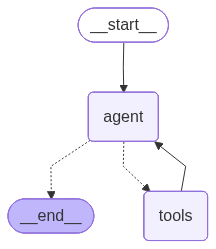

In [20]:
agent = create_agent()
agent

In [22]:
query = "What is the current weather in Ho Chi Minh City?"
result = agent.invoke(
    {'messages': [HumanMessage(query)]},
    config={"callbacks": [langfuce_trace]},
)

[AGENT] called Tool get_weather with args {'location': 'Ho Chi Minh City'}
[AGENT] Responding...


In [23]:
result

{'messages': [HumanMessage(content='What is the current weather in Ho Chi Minh City?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3', 'created_at': '2026-06-03T02:14:45.175532032Z', 'done': True, 'done_reason': 'stop', 'total_duration': 51273366862, 'load_duration': 701756737, 'prompt_eval_count': 413, 'prompt_eval_duration': 22134908434, 'eval_count': 123, 'eval_duration': 28353222579, 'logprobs': None, 'model_name': 'qwen3', 'model_provider': 'ollama'}, id='lc_run--019e8b42-3a6d-7902-8c10-d3777e15662f-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'Ho Chi Minh City'}, 'id': '439a8ac9-4e78-4518-8f3c-5c7e8d6af3d1', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 413, 'output_tokens': 123, 'total_tokens': 536}),
  ToolMessage(content='{"current_condition": [{"FeelsLikeC": "31", "FeelsLikeF": "88", "cloudcover": "75", "humidity": "82", "observation_time": "02:13 AM

In [24]:
result['messages'][-1].pretty_print()

================================== Ai Message ==================================

Here's a summary and analysis of the weather data for **June 25, 2024**:

---

### **Overall Weather Summary**
- **Date**: 2024-06-25  
- **Daytime Temperature Range**: **26°C (79°F)** to **32°C (89°F)**  
- **Sunlight Duration**: **10.8 hours** (likely midday to early evening)  
- **UV Index**: Peaks at **10** (extremely high) around 12:00 PM.  

---

### **Hourly Forecast Highlights**
1. **Morning (06:00–10:00)**  
   - **Sunny** with temperatures rising from **26°C** to **30°C**.  
   - **Humidity**: 66–75% (moderate).  
   - **Wind**: Light (15–19 km/h).  

2. **Midday (12:00–15:00)**  
   - **Patchy rain nearby** (weather code 176).  
   - **Temperature**: **30°C** (86°F).  
   - **UV Index**: **10** (extremely high).  
   - **Wind**: Stronger gusts (19–23 km/h).  

3. **Afternoon (15:00–18:00)**  
   - **Cloudy** skies with temperatures dropping to **32°C** (89°F).  
   - **Humidity**: 60–66% (low t

In [25]:
query = "What is the current weather in Ha Noi, VietNam? and What is 4*56 and 3-90"

result = agent.invoke({'messages': [HumanMessage(query)]}, config={'callbacks': [langfuce_trace]})

[AGENT] called Tool get_weather with args {'location': 'Ha Noi, VietNam'}
[AGENT] called Tool calculate with args {'expression': '4*56'}
[AGENT] called Tool calculate with args {'expression': '3-90'}
[TOOL] calculate ('4*56') -> '224'
[TOOL] calculate ('3-90') -> '-87'
[AGENT] Responding...


In [26]:
result

{'messages': [HumanMessage(content='What is the current weather in Ha Noi, VietNam? and What is 4*56 and 3-90', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3', 'created_at': '2026-06-03T02:34:32.368676532Z', 'done': True, 'done_reason': 'stop', 'total_duration': 154242908704, 'load_duration': 16726928170, 'prompt_eval_count': 429, 'prompt_eval_duration': 26257478619, 'eval_count': 542, 'eval_duration': 110851735454, 'logprobs': None, 'model_name': 'qwen3', 'model_provider': 'ollama'}, id='lc_run--019e8b52-c5b1-7bd3-9180-39989076710e-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'Ha Noi, VietNam'}, 'id': 'a9f061b1-42c3-4760-97d7-6faa011bf19a', 'type': 'tool_call'}, {'name': 'calculate', 'args': {'expression': '4*56'}, 'id': '2f52c271-78a8-4b5d-8415-6bee5e49af6e', 'type': 'tool_call'}, {'name': 'calculate', 'args': {'expression': '3-90'}, 'id': '98104c61-5c01-4cc0-acb2-22266eadb70c', 'type': 't

In [ ]:
result['messages'][-1].pretty_print()